### Task 1: Designing a Heuristic for a Warehouse Robot

In [2]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations

locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph

warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    },

    "Packing_Station": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):
    x1 = locations[current][0]
    y1 = locations[current][1]

    x2 = locations[goal][0]
    y2 = locations[goal][1]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 1)



# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")

for location in locations:
    value = heuristic(location, goal)
    print(f"{location},: , {value:.2f}")

Heuristic Values
----------------
Receiving_Area,: , 9.20
Storage_A,: , 7.10
Storage_B,: , 6.30
Sorting_Area,: , 5.00
Inspection_Area,: , 2.20
Packing_Station,: , 0.00


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [4]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# 6. Find minimum-cost path
## The primary function to find the shortest path in the Python networkx library 
### 1. Unweighted shortest path (ignores 'weight', finds fewest number of edges)
### 2. Weighted shortest path (minimizes the sum of the 'weight' attribute)
solution_path = nx.shortest_path( # reaturn the path e.g. A → B → C
    G,#pass the graph object
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length( #return the numeric value
    G, #pass the graph object
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


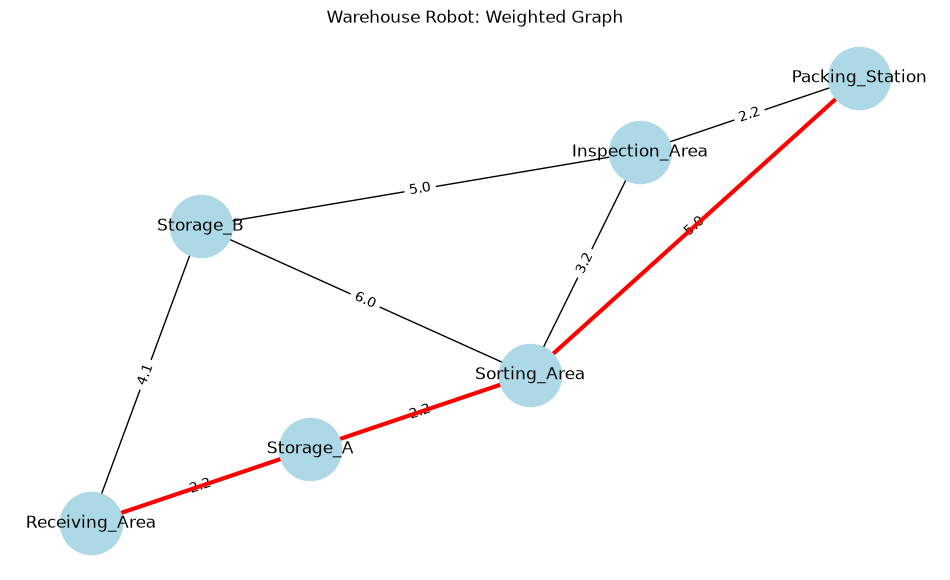

In [34]:
# 7. Visualize graph

pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="lightblue",
    node_size=2000
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True
)

nx.draw_networkx_labels(
    G,
    pos
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)


path_edges = []

for i in range(len(solution_path) - 1):
    path_edges.append((solution_path[i], solution_path[i + 1]))

# Highlight solution path
nx.draw_networkx_edges(
    G,
    pos,
    
    edgelist=path_edges,
    edge_color="red",
    width=3,
    arrows=True
)


plt.title("Warehouse Robot: Weighted Graph")
plt.axis("off")
plt.show()

In [31]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("***********************************")

goal = "Packing_Station"
for node in warehouse_graph:
    hn = heuristic(node, goal)
    for neighbor, cost in warehouse_graph[node].items():
        hm = heuristic(neighbor, goal)
        if hn > hm + cost:
            print("Condition failed:", node, "->", neighbor)
        else:
            print("Condition satisfied:", node, "->", neighbor)
        


Heuristic Condition Verification
***********************************
Condition satisfied: Receiving_Area -> Storage_A
Condition satisfied: Receiving_Area -> Storage_B
Condition satisfied: Storage_A -> Sorting_Area
Condition satisfied: Storage_B -> Inspection_Area
Condition satisfied: Storage_B -> Sorting_Area
Condition satisfied: Sorting_Area -> Inspection_Area
Condition satisfied: Sorting_Area -> Packing_Station
Condition satisfied: Inspection_Area -> Packing_Station


write down your observation in one line:

the heuristic for all nodes are admissible

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [42]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph

airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):
    x1 = locations[current][0]
    y1 = locations[current][1]

    x2 = locations[goal][0]
    y2 = locations[goal][1]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 1)


# 4. GBFS

def greedy_best_first_search(start, goal, graph):
    
    visited = set()
    
    queue = []
    
    heapq.heappush(queue, (heuristic(start, goal), start))
    
    parent = {start: None}

    while queue:
        h, current = heapq.heappop(queue)

        if current in visited:
            continue

        visited.add(current)

        if current==goal:
            # Reconstruct path
            path = []

            while current!=start:
                path.append(current)
                current = parent[current]

            path.append(start)
            path.reverse()
            return path, visited


        for neighbor in graph[current]:
            parent[neighbor] = current
            heapq.heappush(queue, (heuristic(neighbor, goal), neighbor))
            
    return None
    

# Calculate actual path cost
    
total_cost = 0

for i in range(len(path) - 1):
    current = path[i]
    next_node = path[i + 1]

    total_cost += airport_graph[current][next_node]




# 5. Run GBFS

# define the start state
start = "Baggage_Area"

# define the goal state
goal = "Departure_Gate"


path, expansion_order = greedy_best_first_search(
    start,
    goal,
    airport_graph
)



print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

GBFS
--------------------------------
Expansion order:
Terminal_Hall -> Checkpoint -> Departure_Gate -> Baggage_Area

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30


#### NetworkX visualization

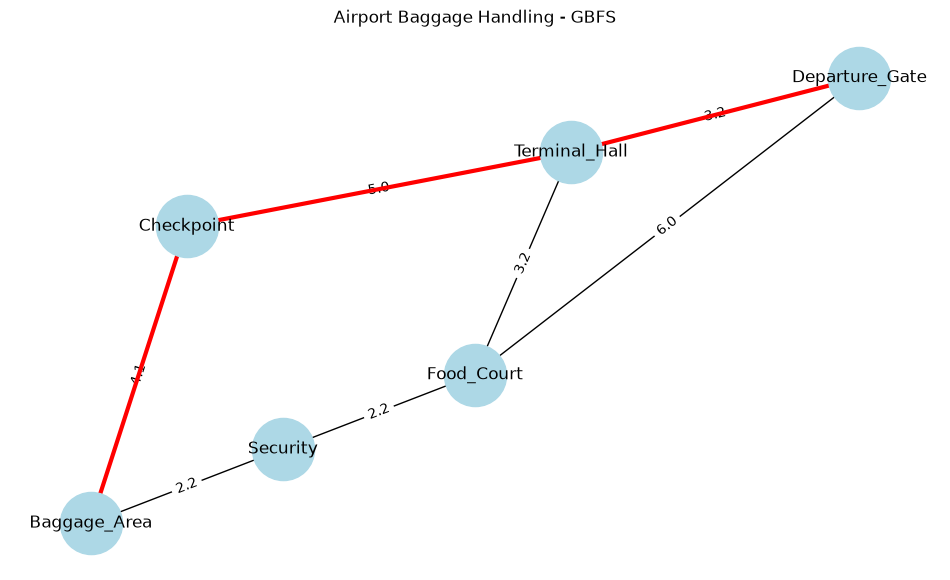

In [44]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

pos = locations

plt.figure(figsize=(12, 7))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="lightblue",
    node_size=2000
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True
)

# Draw node labels
nx.draw_networkx_labels(
    G,
    pos
)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

# Create edges for solution path
path_edges = []

for i in range(len(path) - 1):
    path_edges.append(
        (path[i], path[i + 1])
    )

# Highlight solution path
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=3,
    arrows=True
)

plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()

### Task 3: A* Search for Emergency Supply Robot

In [56]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates

locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph

hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    },

    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Emergency_Ward": {}
}


# 3. Euclidean heuristic

def heuristic(current, goal):

    x1 = locations[current][0]
    y1 = locations[current][1]

    x2 = locations[goal][0]
    y2 = locations[goal][1]

    distance = math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

    return round(distance, 1)


# 4. Path reconstruction

def reconstruct_path(came_from, current):

    path = []

    while current is not None:
        path.append(current)
        current = came_from[current]

    path.reverse()

    return path


# 5. A* Search

def a_star_search(start, goal, graph):

    expansion_order = []
    queue = []

    # g(n) = cost from start to current node
    gn = {start: 0}

    # Store the previous node
    parent = {start: None}

    # f(n) = g(n) + h(n)
    fn = gn[start] + heuristic(start, goal)

    heapq.heappush(queue, (fn, start))

    while queue:

        fn, current = heapq.heappop(queue)

        # Record expansion order
        expansion_order.append(current)

        # Goal reached
        if current == goal:
            path = reconstruct_path(parent, current)
            total_cost = gn[goal]
            return path, expansion_order, gn

        # Explore neighbors
        for neighbor, cost in graph[current].items():

            # Calculate new g(n)
            new_g = gn[current] + cost

            # If this is a better path
            if neighbor not in gn or new_g < gn[neighbor]:

                gn[neighbor] = new_g

                parent[neighbor] = current

                # Calculate f(n) = g(n) + h(n)
                fn = gn[neighbor] + heuristic(neighbor, goal)

                heapq.heappush(queue,(fn, neighbor))

    return None, expansion_order, None


# 6. Run A*

start = "Pharmacy"
goal = "Emergency_Ward"

path, expansion_order, gn = a_star_search(
    start,
    goal,
    hospital_graph
)


# 7. Display results

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {gn[goal]:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [57]:
# you may also replace it with dataframe it is completely your own choice

print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:

    g = gn[node]
    h = heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.80     10.00
Nursing_Station           4.40      5.70     10.10
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

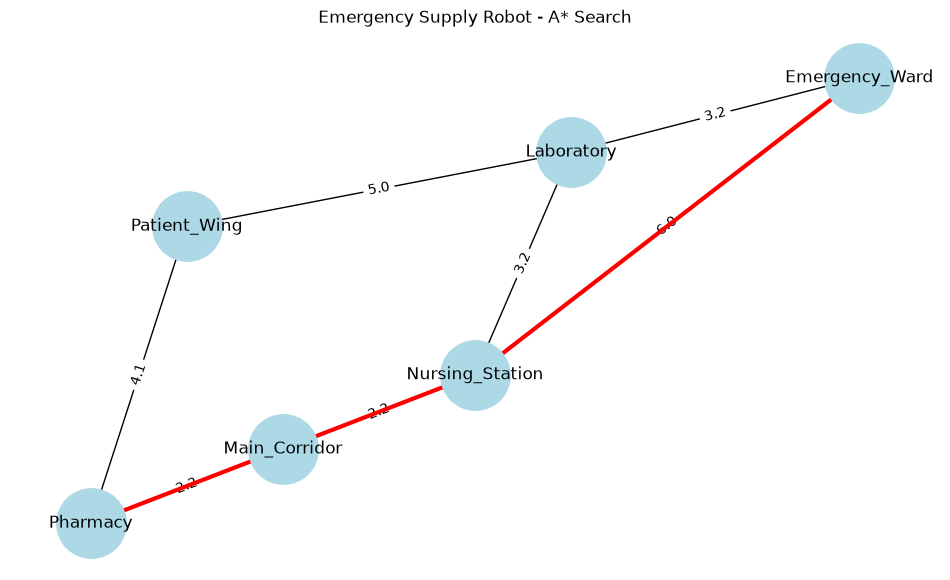

In [62]:
# 7. NetworkX visualization

G = nx.DiGraph()

# Add nodes and edges
for node, neighbors in hospital_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=cost
        )


pos = locations

plt.figure(figsize=(12, 7))


# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color="lightblue",
    node_size=2500
)


# Draw all edges
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True
)


# Draw node labels
nx.draw_networkx_labels(
    G,
    pos
)


# Draw edge weights
edge_labels = nx.get_edge_attributes(
    G,
    "weight"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)


# Create edges for the A* solution path
path_edges = []

for i in range(len(path) - 1):

    path_edges.append(
        (path[i], path[i + 1])
    )


# Highlight the A* solution path
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=3,
    arrows=True
)


plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()


GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

### Task 4: Weighted A* for Autonomous Delivery Drone

In [66]:
import math
import heapq
import pandas as pd


# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}


# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },

    "Zone_C": {
        "Zone_D": 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    },

    "Customer_Building": {}
}


# 3. Euclidean Heuristic

def heuristic(node, goal):

    x1 = locations[node][0]
    y1 = locations[node][1]

    x2 = locations[goal][0]
    y2 = locations[goal][1]

    distance = math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

    return round(distance, 1)


# 4. Path Reconstruction

def reconstruct_path(parent, current):

    path = []

    while current is not None:
        path.append(current)
        current = parent[current]

    path.reverse()

    return path


# 5. Display Heuristic Values

goal = "Customer_Building"

heuristic_data = []

for node in locations:

    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })


heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))


# 6. Weighted A* Search
# f(n) = g(n) + w * h(n)

def weighted_a_star(start, goal, graph, weight):

    expansion_order = []
    queue = []

    # g(n) = cost from start to current node
    gn = {start: 0}

    # Store previous node
    parent = {start: None}

    # Calculate f(n)
    fn = gn[start] + weight * heuristic(start, goal)

    heapq.heappush(
        queue,
        (fn, start)
    )

    while queue:

        fn, current = heapq.heappop(queue)

        expansion_order.append(current)

        # Goal reached
        if current == goal:

            path = reconstruct_path(
                parent,
                current
            )

            total_cost = gn[goal]

            return path, total_cost, expansion_order

        # Explore neighbors
        for neighbor, cost in graph[current].items():

            # Calculate new g(n)
            new_g = gn[current] + cost

            # If this is a better path
            if neighbor not in gn or new_g < gn[neighbor]:

                gn[neighbor] = new_g

                parent[neighbor] = current

                # Weighted A*
                # f(n) = g(n) + w * h(n)

                fn = (
                    gn[neighbor]
                    + weight * heuristic(neighbor, goal)
                )

                heapq.heappush(
                    queue,
                    (fn, neighbor)
                )

    return None, None, expansion_order


# 7. Run Weighted A* for All Required Weights

start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:

    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })


# 8. Display Results in DataFrame

results_df = pd.DataFrame(results)

print("\nWeighted A* Results:")
print("************************")

print(
    results_df[
        [
            "Weight",
            "Solution Path",
            "Total Cost",
            "Nodes Expanded"
        ]
    ].to_string(index=False)
)


# 9. Display Detailed Expansion Orders

print("\nDetailed Expansion Orders:")
print("*******************************")

for result in results:

    print(f"\nWeight = {result['Weight']}")

    print(
        "Expansion Order:",
        result["Expansion Order"]
    )

Heuristic Values:
               Node  h(n)
Distribution_Center  10.0
             Zone_A   7.8
             Zone_B   7.3
             Zone_C   5.7
             Zone_D   3.2
  Customer_Building   0.0

Weighted A* Results:
************************
 Weight                                             Solution Path  Total Cost  Nodes Expanded
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5
    1.5 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               4
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4

Detailed Expansion Orders:
*******************************

Weight = 1
Expansion Order: Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building

Weight = 1.5
Expansion Order: Distribution_Center → Zone_A → Zone_C → Customer_Building

Weight = 2
Expansion Order: Distribut

#### NetworkX visualization

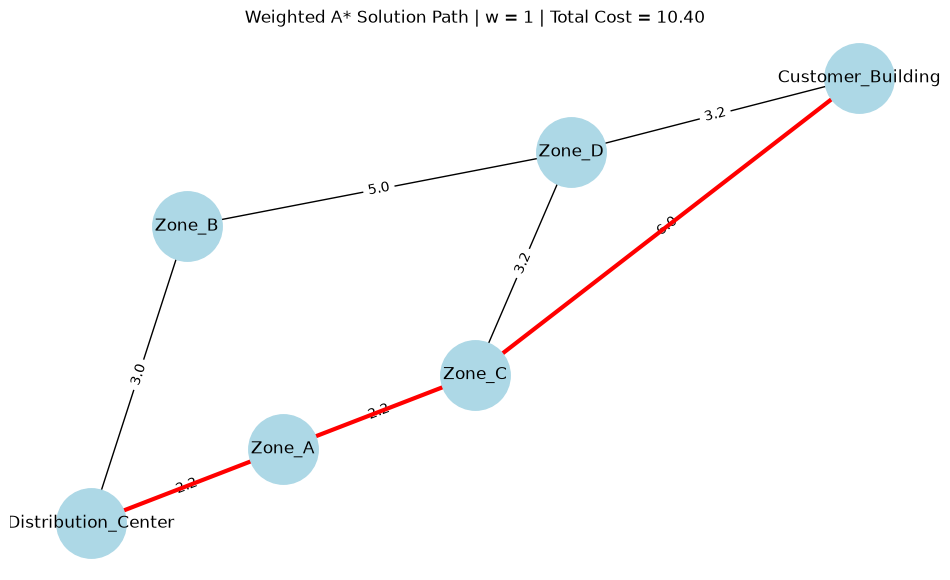

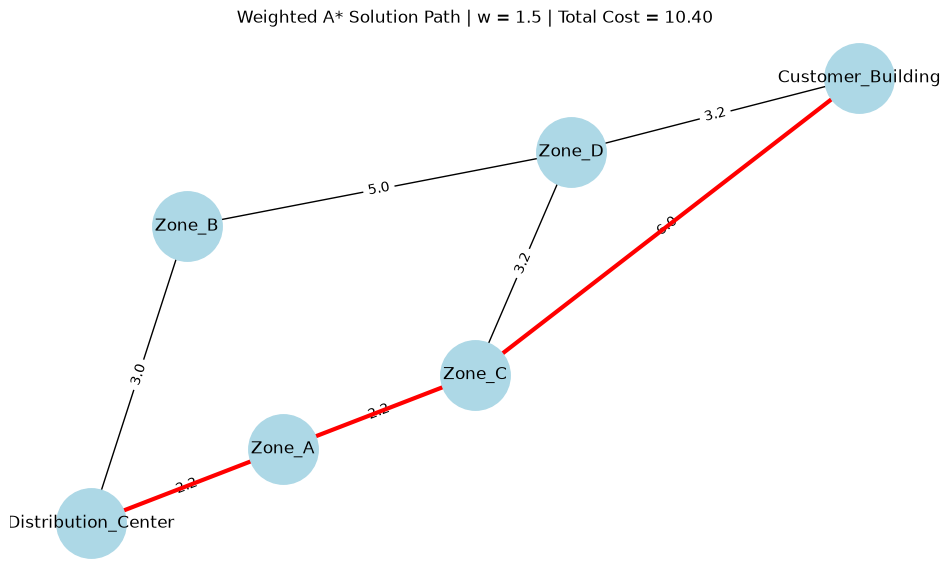

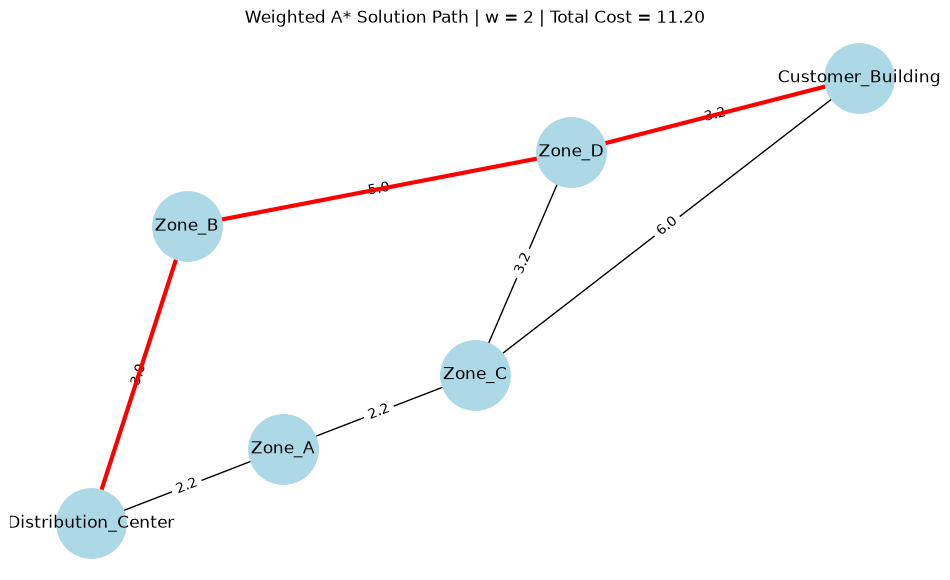

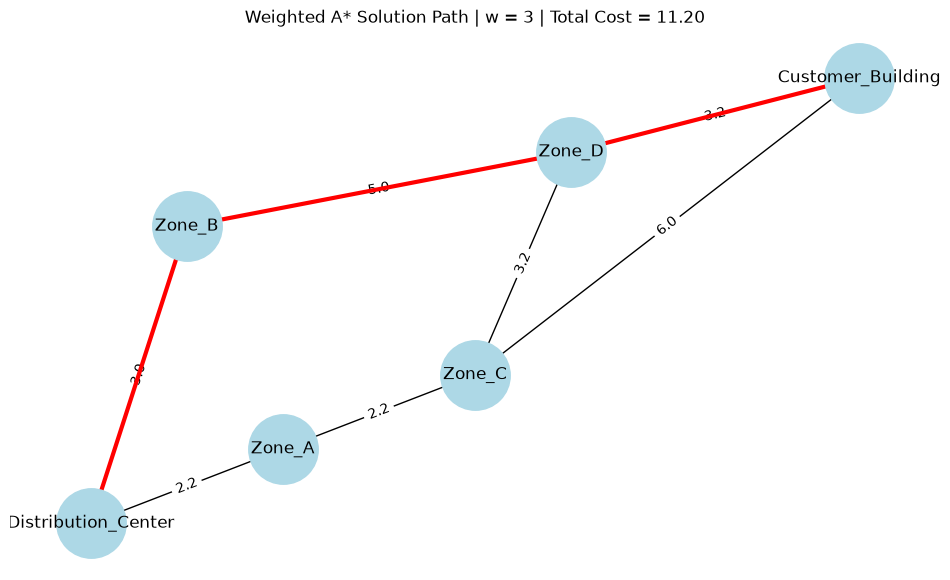

In [67]:
import networkx as nx
import matplotlib.pyplot as plt


# 1. Create NetworkX Graph

G = nx.DiGraph()


# Add nodes with their coordinates

for node, position in locations.items():

    G.add_node(
        node,
        pos=position
    )


# Add weighted edges

for node, neighbors in graph.items():

    for neighbor, cost in neighbors.items():

        G.add_edge(
            node,
            neighbor,
            weight=cost
        )


# 2. Node Positions

pos = locations


# 3. Visualize Weighted A* Result for Each Weight

for w in weights:

    # Run Weighted A*
    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )


    # Draw nodes

    plt.figure(figsize=(12, 7))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color="lightblue",
        node_size=2500
    )


    # Draw all edges

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True
    )


    # Draw node labels

    nx.draw_networkx_labels(
        G,
        pos
    )


    # Draw edge weights

    edge_labels = nx.get_edge_attributes(
        G,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )


    # Create edges for solution path

    path_edges = []

    for i in range(len(path) - 1):

        path_edges.append(
            (path[i], path[i + 1])
        )


    # Highlight solution path

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        edge_color="red",
        width=3,
        arrows=True
    )


    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.axis("off")

    plt.show()

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G